# RADAR tutorial: anomalous-cell detection, alignment, and resolution

This notebook demonstrates how to use RADAR to detect anomalous cells, align target datasets, and resolve anomalous cells into fine-grained subtypes.

RADAR contains three phases:

1. Phase I: anomalous-cell detection
2. Phase II: multi-sample alignment
3. Phase III: anomalous-cell resolution

## Setting work path

In [2]:
import os
import sys
from pathlib import Path

# Current notebook path
notebook_path = Path.cwd()

# Project root: docs/tutorial/RADAR_workflow.ipynb -> project root
project_root = notebook_path.parents[1]

src_path = project_root / "src"
data_path = project_root / "data"
output_path = project_root / "output" / "radar_workflow"

output_path.mkdir(parents=True, exist_ok=True)

# Add src to Python path
sys.path.insert(0, str(src_path))

## Load reference and target datasets

RADAR takes a healthy reference dataset and one or more target datasets as input.

The reference dataset contains normal cells, while the target dataset may contain both normal and anomalous cells.

In [3]:
import scanpy as sc
from IPython.display import display

ref_path = data_path / "ref_clean_colorectum.h5ad"
tgt_path = data_path / "tgt_clean_colorectum.h5ad"

ref = sc.read_h5ad(ref_path)
tgt = sc.read_h5ad(tgt_path)

print("\nReference metadata:")
display(ref.obs.head())

print("\nTarget metadata:")
display(tgt.obs.head())


Reference metadata:


,hash_label,hash_cluster,n_genes,hashed,group,treatment,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,...,BMI,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
TGTCAGAGTACGTTCA-1-1,TotalSeq-B0254,4,1102,TRUE,primary,none,1117,4648.0,2518.0,54.173840,...,36.4,tissue,enterocyte,10x 3' v3,normal,male,ascending colon,European American,29-year-old stage,5F4XbR-S%0
AACCCAAAGCATCCCG-1-2,TotalSeq-B0254,5,3537,TRUE,primary,none,3574,13114.0,2335.0,17.805399,...,25,tissue,goblet_cell,10x 3' v3,normal,male,ascending colon,African American,53-year-old stage,j*n^E04+po
AGTTCGAGTTGGGACA-1-2,TotalSeq-B0256,3,2409,TRUE,primary,none,2440,10661.0,3133.0,29.387486,...,25,tissue,goblet_cell,10x 3' v3,normal,male,transverse colon,African American,53-year-old stage,H<3F-CRGUL
AACGTCACAGGTTCCG-1-0,TotalSeq-B0256,2,1595,TRUE,primary,none,1614,3309.0,593.0,17.920822,...,52.2,tissue,enterocyte,10x 3' v3,normal,male,descending colon,European American,45-year-old stage,YYCk)eBnrd
CTACTATGTCGTCTCT-1-2,TotalSeq-B0256,3,3187,TRUE,primary,none,3228,12773.0,2536.0,19.854380,...,25,tissue,goblet_cell,10x 3' v3,normal,male,transverse colon,African American,53-year-old stage,BPfTJ-ZI9Y



Target metadata:


,biosample_id,donor_id,TissueSource,ProcessingMethod,PatientTypeID,sex_ontology_term_id,Site,Grade,TumorStage,LymphNodeStatus,...,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,cell_state_label,normal_coarse_type,n_genes
C125_N_1_1_1_c1_v2_id-CCTATTAGTGCTAGCC,C125_N_1_1_1_c1_v2,C125,MGH,CD45+,C125_N,PATO:0000384,left,low,notT4,N+,...,10x 3' v2,normal,male,colorectum,European American,49-year-old stage,3ex)+3u3R{,stem_cell,stem_cell,5131
C143_N_1_1_0_c1_v2_id-TCTTCGGTCCCTAATT,C143_N_1_1_0_c1_v2,C143,MGH,unsorted,C143_N,PATO:0000383,right,low,notT4,N-,...,10x 3' v2,normal,female,colorectum,European American,55-year-old stage,mJ=37ztPee,stem_cell,stem_cell,3407
C116_N_0_2_2_c1_v2_id-TTAGGCACAAGACACG,C116_N_0_2_2_c1_v2,C116,DFCI,mixUnsortCD45,C116_N,PATO:0000384,right,low,notT4,N-,...,10x 3' v2,normal,male,colorectum,European American,72-year-old stage,&s6^Zt*0Ms,stem_cell,stem_cell,3445
C112_N_0_1_2_c1_v2_id-CCGTTCACACGGTAAG,C112_N_0_1_2_c1_v2,C112,DFCI,mixUnsortCD45,C112_N,PATO:0000384,right,low,notT4,N-,...,10x 3' v2,normal,male,colorectum,European American,50-year-old stage,-Eq)he0IN},stem_cell,stem_cell,4042
C124_N_0_3_1_c1_v2_id-GAGGTGAGTTAAGGGC,C124_N_0_3_1_c1_v2,C124,DFCI,CD45+,C124_N,PATO:0000383,left,high,T4,N+,...,10x 3' v2,normal,female,colorectum,Asian,81-year-old stage,#`Z#9w*qy1,stem_cell,stem_cell,5093


## Phase I: Train RADAR for anomalous-cell detection

In [ ]:
import radar
import pandas as pd
configs = radar.AnomalyConfigs()

# build model-specific configs
configs.build()
configs.clear()

,value
n_epochs,300
batch_size,512
learning_rate,0.0001
n_critic,1
gamma,0.1
lambda_z,0.1
use_memory_bank,True
memory_size,512
random_state,2026
n_genes,3000


In [18]:
model = radar.AnomalyModel(configs)
model.train(ref)

Begin to train RADAR on the reference dataset...


Training Epochs: 100%|██████████| 300/300 [01:49<00:00,  2.73it/s, D_Loss=0.337, G_Loss=-0.287, df_m=0.477, df_s=0.332, dr_m=-0.978, dr_s=0.991, t_m=1.45, t_s=1.05, xL1=0.393, zL1=4.41]   

Training process has been finished.


Begin to detect anomalies on the target dataset...
Ref mean score: 0.998924
Target mean score: 0.998843
Anomalous spots have been detected.
Begin to detect anomalies on the target dataset...
Ref mean score: 0.998924
Target mean score: 0.998643
Anomalous spots have been detected.


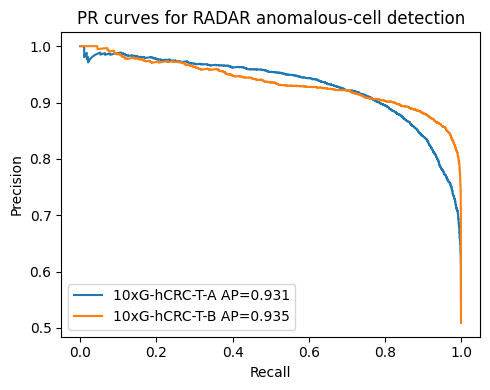

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

label_col = "cell_state_label"   
pos_labels = ["tumor02_MMRp", "tumor02_MMRd"]

datasets = {
    "10xG-hCRC-T-A": tgt[tgt.obs["assay"] == "10x 3' v2"].copy(),
    "10xG-hCRC-T-B": tgt[tgt.obs["assay"] == "10x 3' v3"].copy(),
}

plt.figure(figsize=(5, 4))

for name, adata in datasets.items():
    score = model.predict(adata, run_gmm=False)

    y_true = adata.obs[label_col].isin(pos_labels).astype(int).values

    precision, recall, _ = precision_recall_curve(y_true, score)
    ap = average_precision_score(y_true, score)

    plt.plot(recall, precision, label=f"{name} AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR curves for RADAR anomalous-cell detection")
plt.legend()
plt.tight_layout()
plt.show()

## Phase II: Multi-sample alignment

In [5]:
import os
import scanpy as sc

# Go to project root
os.chdir(project_root)

# Run Phase II script directly
!bash scripts/02_phase2.sh


/data1011/yuzimu/miniconda3/envs/proteinnpt_env/lib/python3.10/runpy.py:126: RuntimeWarning: 'radar.alignment' found in sys.modules after import of package 'radar', but prior to execution of 'radar.alignment'; this may result in unpredictable behaviour
  warn(RuntimeWarning(msg))
Training:   0%|                                         | 0/500 [00:00<?, ?it/s]/data1011/yuzimu/RADAR/src/radar/alignment.py:320: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  logs_d_all.append({k: float(v) for k, v in d_log.items()})
Training: 100%|███████████████████████████████| 500/500 [12:14<00:00,  1.47s/it]
saved_h5ad: data/corrected_tgt_ref.h5ad
available_domains: ["10x 3' v2", "10x 3' v3", 'REF__ref']
ref_domain_name: REF__ref
target_domain_requested: 10x 3' v2
d_steps: 1
g_steps: 1
domain_balance_power: 0.5
t

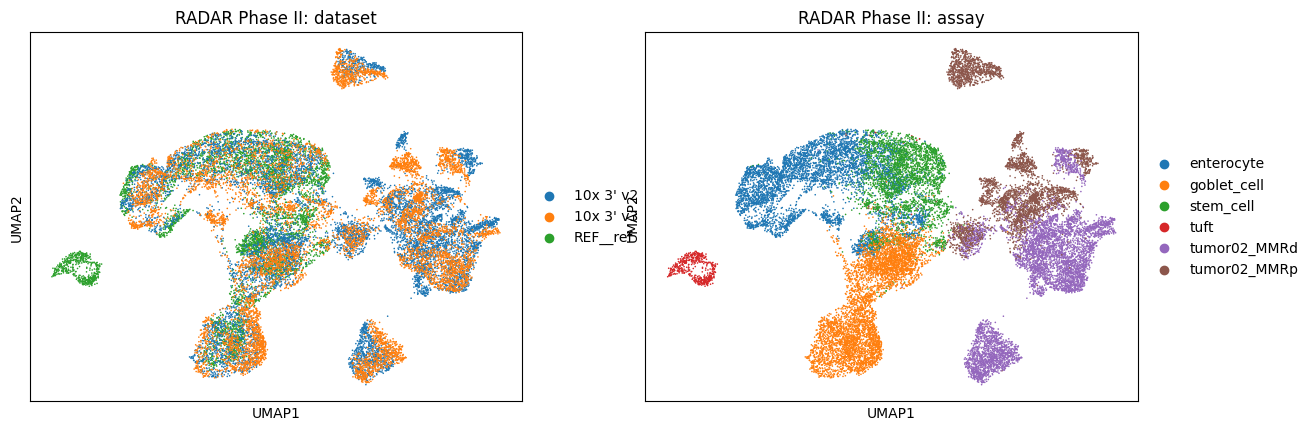

In [8]:
import scanpy as sc

corrected = sc.read_h5ad(data_path / "corrected_tgt_ref.h5ad")

sc.tl.pca(corrected, n_comps=30)
sc.pp.neighbors(corrected, use_rep="X_pca", n_neighbors=15, n_pcs=30)
sc.tl.umap(corrected)

sc.pl.umap(
    corrected,
    color=["assay_eval", "bio_label"],
    title=[
        "RADAR Phase II: dataset",
        "RADAR Phase II: assay",
        "RADAR Phase II: biological label",
    ],
)

## Phase III: AC resolution

In [4]:
import torch
import pandas as pd
import radar

ckpt_path = project_root / "ckpt"
adata = sc.read_h5ad(project_root / "data" / "corrected_tgt_ref.h5ad")
pred = pd.read_csv(project_root / "output" / "phase1_pred_ASCs.csv")

# 2. Load trained Phase-I generator
generator = torch.load(ckpt_path / "phase1_G.pth", map_location="cpu", weights_only=False)

# 3. Select predicted abnormal cells
cell_col = "cell_id"

ac_cells = pred.loc[pred["pred"].astype(str).isin(["abnormal", "1"]), cell_col].astype(str)
adata_sub = adata[adata.obs_names.astype(str).isin(ac_cells)].copy()

print("Detected ACs:", adata_sub.n_obs)

# 4. Configure and train Phase-III subtype model
configs = radar.SubtypeConfigs()
configs.n_genes = adata_sub.n_vars
configs.GPU = "cuda:0"
configs.n_epochs = 1000
configs.batch_size = 64

configs.build()
configs.clear()

num_types = 2  # CRC: MMRp and MMRd

model = radar.SubtypeModel(generator, num_types, configs)
subtype = model.train(adata_sub)

# 5. Save subtype labels into AnnData
adata_sub.obs["RADAR_subtype"] = subtype.astype(str)

/data1011/yuzimu/miniconda3/envs/proteinnpt_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Detected ACs: 9621


Training Epochs:   8%|▊         | 80/1000 [03:34<41:07,  2.68s/it, delta=0.0000, mean_loss=0.0863]


/tmp/ipykernel_1922909/483756714.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['1' '1' '1' ... '0' '0' '0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[adata_sub.obs_names, "RADAR_subtype"] = adata_sub.obs["RADAR_subtype"].values
/tmp/ipykernel_1922909/483756714.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['tumor02_MMRp' 'tumor02_MMRp' 'tumor02_MMRp' ... 'tumor02_MMRd'
 'tumor02_MMRd' 'tumor02_MMRd']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[adata_sub.obs_names, "RADAR_subtype_name"] = (


RADAR subtype mapping: {'0': 'tumor02_MMRd', '1': 'tumor02_MMRp'}


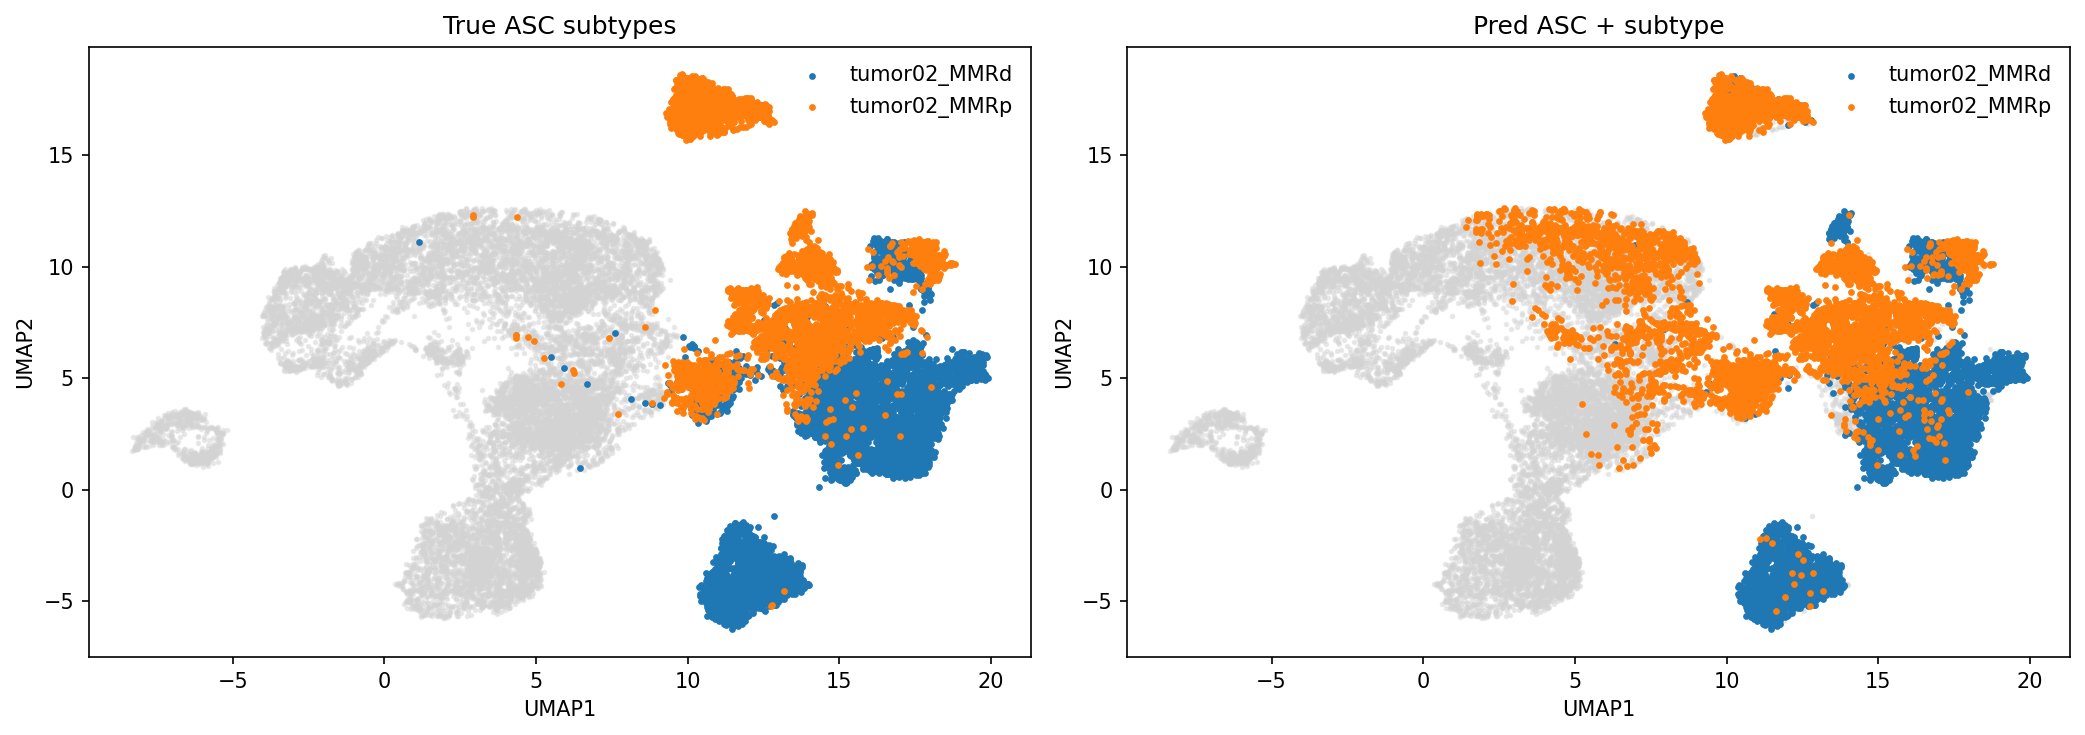

In [5]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

adata_sub.obs["RADAR_subtype"] = subtype.astype(str)
adata.obs["RADAR_subtype"] = np.nan
adata.obs.loc[adata_sub.obs_names, "RADAR_subtype"] = adata_sub.obs["RADAR_subtype"].values

tab = pd.crosstab(adata_sub.obs["RADAR_subtype"], adata_sub.obs["bio_label"])
mapping = tab.idxmax(axis=1).to_dict()
print("RADAR subtype mapping:", mapping)

adata.obs["RADAR_subtype_name"] = np.nan
adata.obs.loc[adata_sub.obs_names, "RADAR_subtype_name"] = (
    adata.obs.loc[adata_sub.obs_names, "RADAR_subtype"].map(mapping)
)

sc.tl.pca(adata, n_comps=30)
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

true_labels = ["tumor02_MMRd", "tumor02_MMRp"]
colors = {"tumor02_MMRd": "tab:blue", "tumor02_MMRp": "tab:orange"}
xy = adata.obsm["X_umap"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

axes[0].scatter(xy[:, 0], xy[:, 1], s=3, c="lightgray", alpha=0.4)
for lab in true_labels:
    mask = adata.obs["bio_label"].astype(str) == lab
    axes[0].scatter(xy[mask, 0], xy[mask, 1], s=5, c=colors[lab], label=lab)
axes[0].set_title("True ASC subtypes")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")
axes[0].legend(frameon=False)

axes[1].scatter(xy[:, 0], xy[:, 1], s=3, c="lightgray", alpha=0.4)
for lab in true_labels:
    mask = adata.obs["RADAR_subtype_name"].astype(str) == lab
    axes[1].scatter(xy[mask, 0], xy[mask, 1], s=5, c=colors[lab], label=lab)
axes[1].set_title("Pred ASC + subtype")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()